In [1]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gokuls/BERT-tiny-emotion-intent")

/Users/tonyma/code/FHE-BERT-Tiny-Emotion/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion", split="test")

In [3]:
import pandas as pd

texts = dataset['text']
token_length = [len(tokenizer.encode(entry['text'], truncation=False)) for entry in dataset]
labels = dataset['label']

df = pd.DataFrame({
    'text': texts,
    'token_length': token_length,
    'label': labels
})

# sort token length
df_token_length = df.sort_values(by='token_length', ascending=True).reset_index(drop=True)

# sort label
df_label = df.sort_values(by='label', ascending=True).reset_index(drop=True)

In [4]:
import numpy as np
print(len(np.unique(token_length))) # unique token length
print(df_token_length.head())
print(df_label.head())

60
                        text  token_length  label
0       im feeling energetic             5      1
1             i feel alarmed             5      4
2            id feel frantic             5      4
3  i feel embarrassed enough             6      0
4       i feel more creative             6      1
                                                text  token_length  label
0  im feeling rather rotten so im not very ambiti...            13      0
1  i couldn t tell if he was sick injured or just...            36      0
2           i am or who i m with i always feel alone            13      0
3  i feel and talk like a disadvantaged child and...            22      0
4  i was feeling emotional crying for no apparent...            22      0


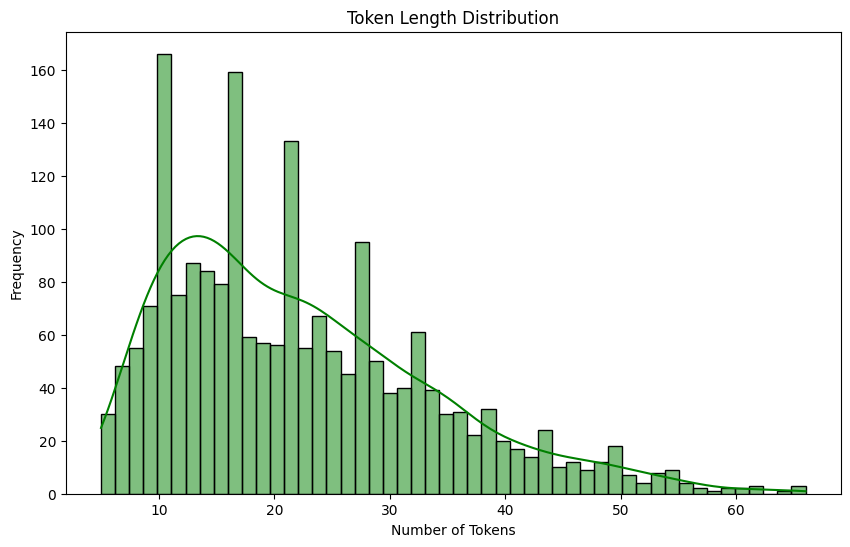

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['token_length'], bins=50, kde=True, color='green')
plt.title("Token Length Distribution")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()


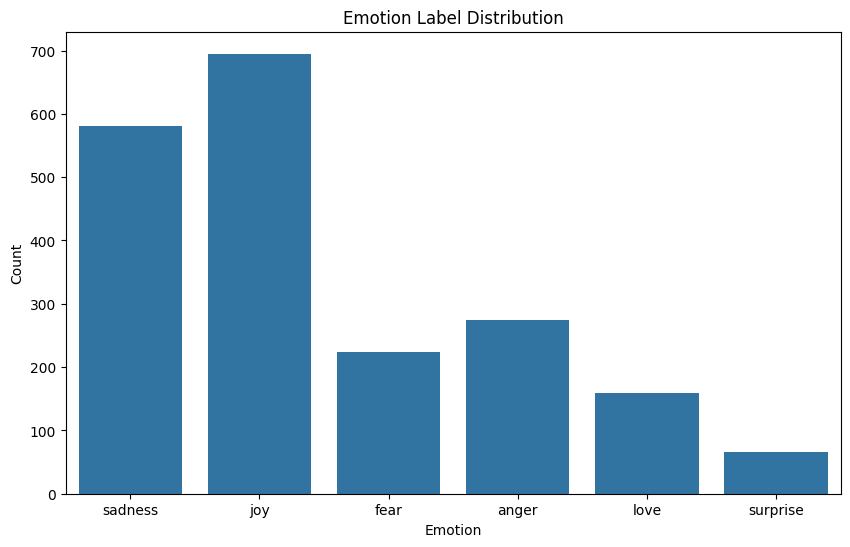

In [6]:
label_mapping = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise",
}

df['emotion'] = df['label'].map(label_mapping)

plt.figure(figsize=(10, 6))
sns.countplot(x='emotion', data=df)
plt.title("Emotion Label Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()